# Bibliotecas e Exploração inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/MarcosOnishi/Tech-Challenge---Fase-4/refs/heads/main/Obesity.csv")

In [ ]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.shape

(2111, 17)

In [ ]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [ ]:
df['Obesity'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
duplicated = df.duplicated()

duplicated_df = pd.DataFrame(duplicated)

duplicated_df[duplicated_df[0] == True]

,0
98,True
106,True
174,True
179,True
184,True
209,True
309,True
460,True
467,True
496,True


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2087 non-null   object 
 1   Age             2087 non-null   float64
 2   Height          2087 non-null   float64
 3   Weight          2087 non-null   float64
 4   family_history  2087 non-null   object 
 5   FAVC            2087 non-null   object 
 6   FCVC            2087 non-null   float64
 7   NCP             2087 non-null   float64
 8   CAEC            2087 non-null   object 
 9   SMOKE           2087 non-null   object 
 10  CH2O            2087 non-null   float64
 11  SCC             2087 non-null   object 
 12  FAF             2087 non-null   float64
 13  TUE             2087 non-null   float64
 14  CALC            2087 non-null   object 
 15  MTRANS          2087 non-null   object 
 16  Obesity         2087 non-null   object 
dtypes: float64(8), object(9)
memory usage:

In [ ]:
df.to_csv('df_clean.csv', index=False)

# Visualização

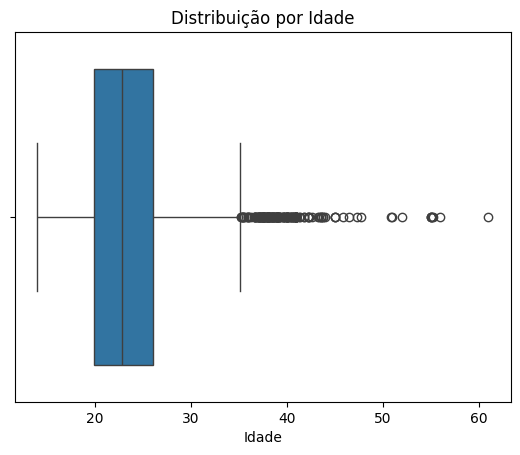

In [ ]:
sns.boxplot(x=df['Age'])
plt.title('Distribuição por Idade')
plt.xlabel('Idade')
plt.show()

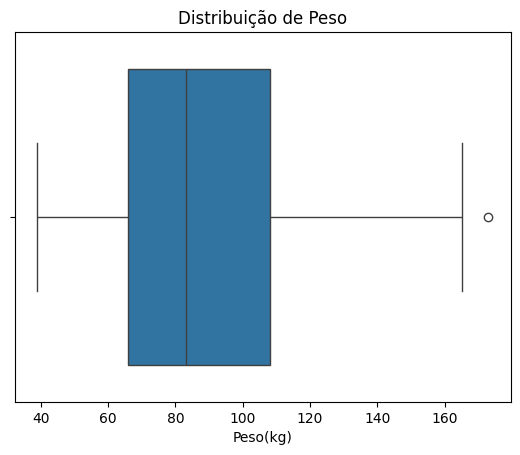

In [ ]:
sns.boxplot(x=df['Weight'])
plt.title('Distribuição de Peso')
plt.xlabel('Peso(kg)')
plt.show()

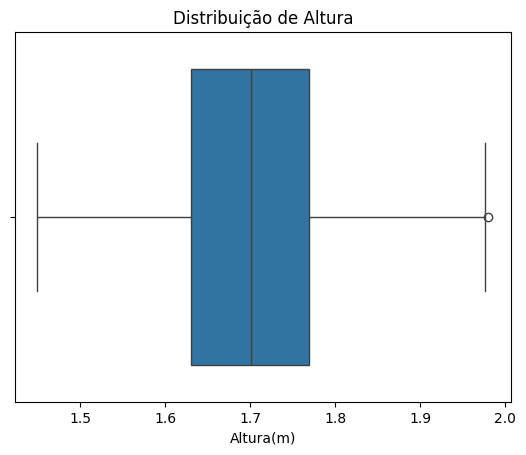

In [ ]:
sns.boxplot(x=df['Height'])
plt.title('Distribuição de Altura')
plt.xlabel('Altura(m)')
plt.show()

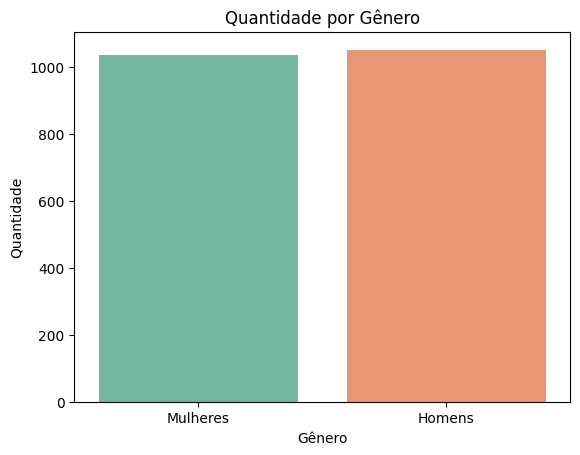

In [ ]:
sns.countplot(x=df['Gender'], hue=df['Gender'], palette='Set2', legend=False)

plt.title('Quantidade por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Mulheres', 'Homens'])
plt.show()

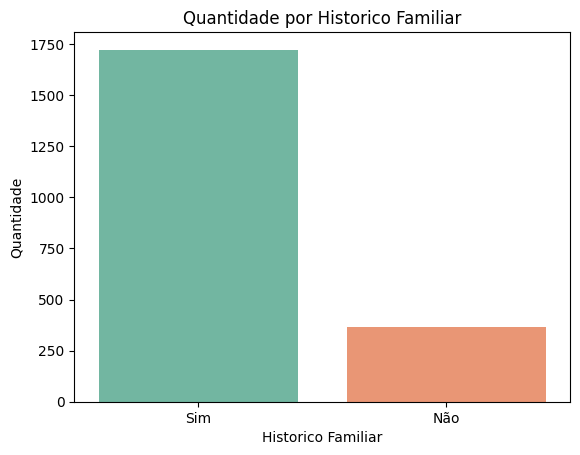

In [ ]:
sns.countplot(x=df['family_history'], hue=df['family_history'], palette='Set2', legend=False)

plt.title('Quantidade por Historico Familiar')
plt.xlabel('Historico Familiar')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Sim', 'Não'])
plt.show()

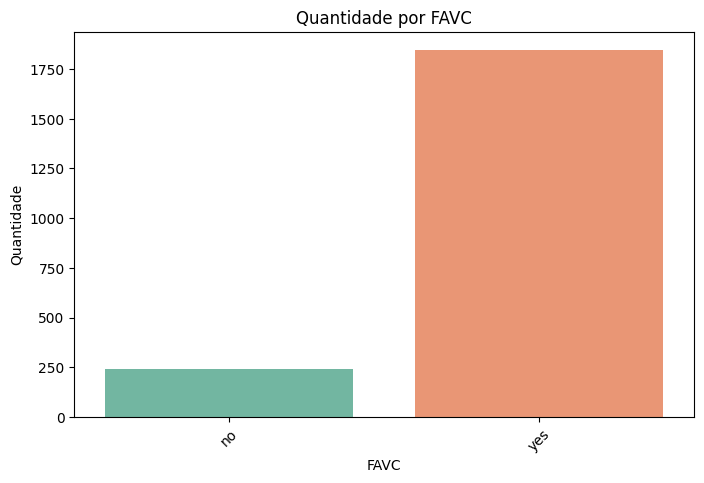

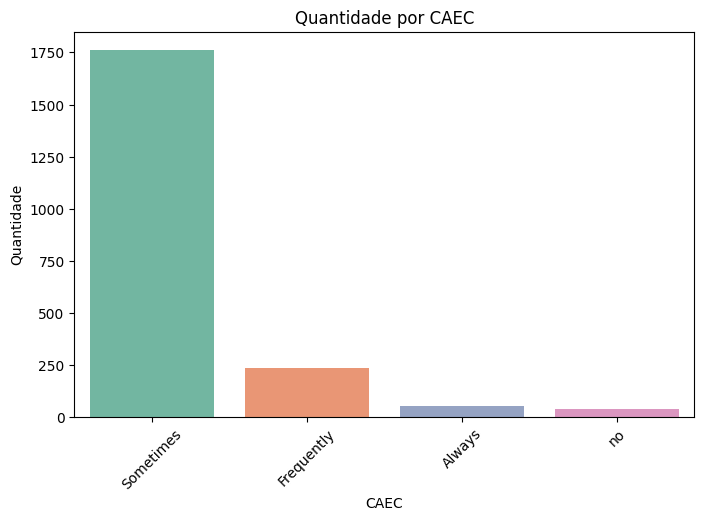

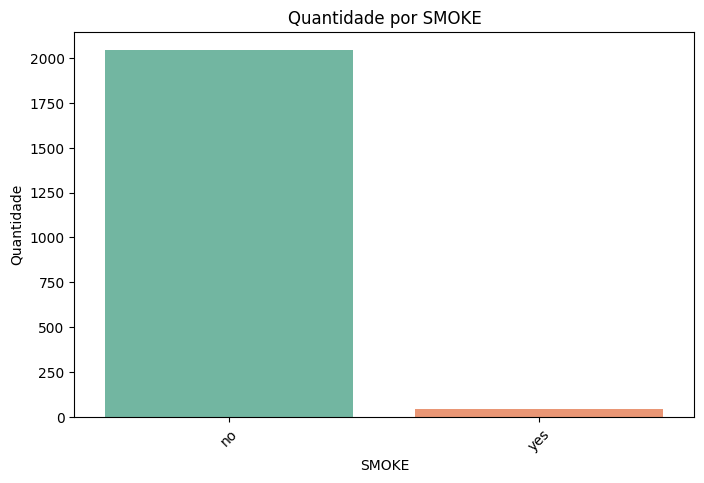

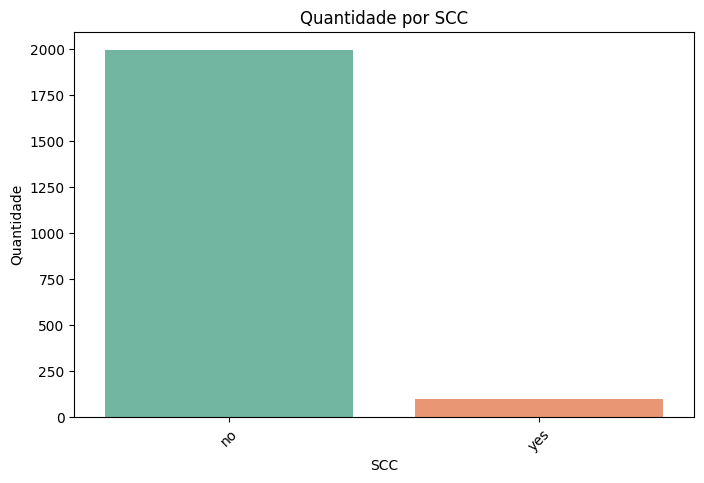

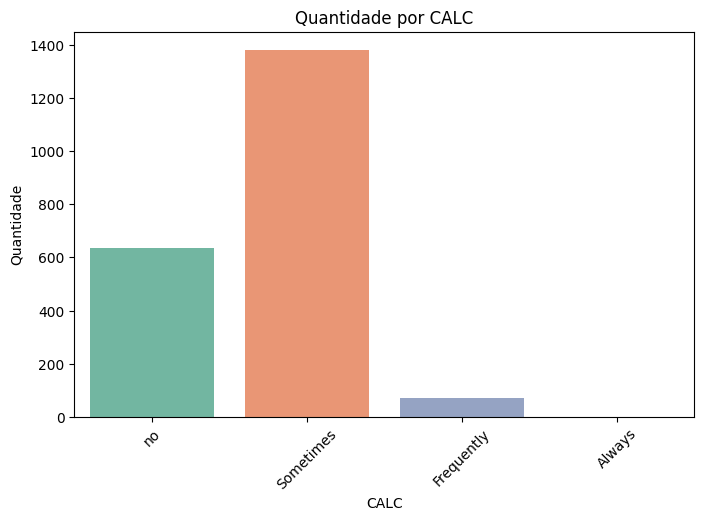

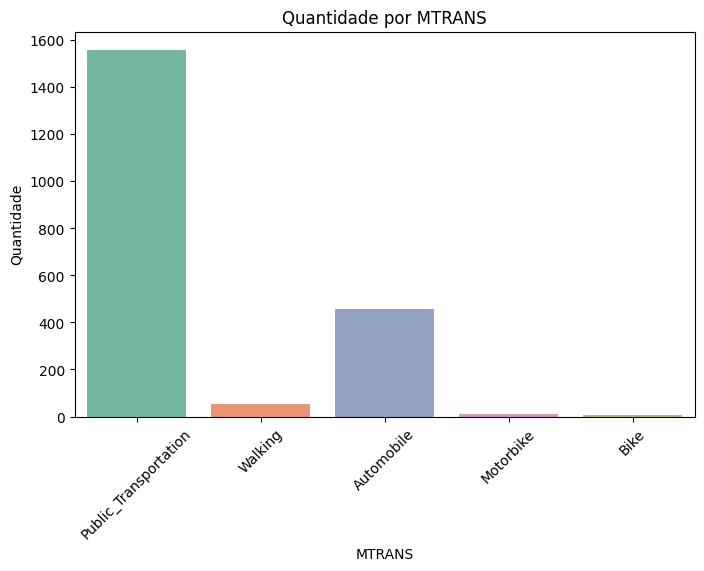

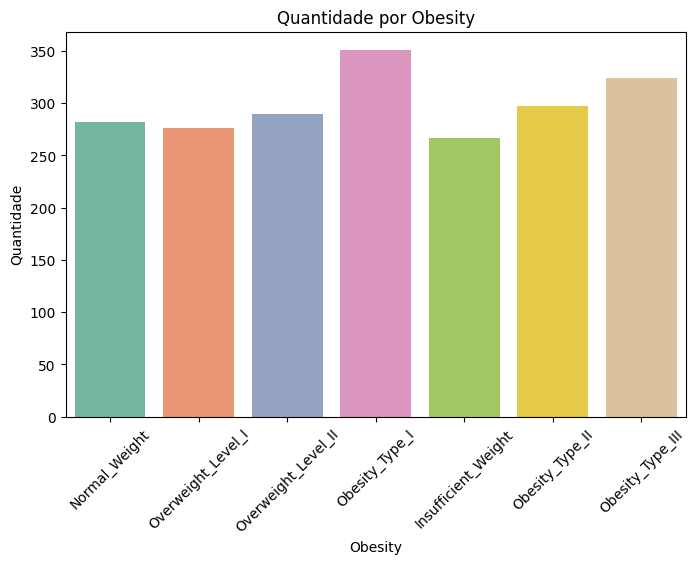

In [ ]:
categorical_cols = ['FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'Obesity']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue=df[col], palette='Set2')
    plt.title(f'Quantidade por {col}')
    plt.ylabel('Quantidade')
    plt.xticks(rotation=45)
    plt.show()

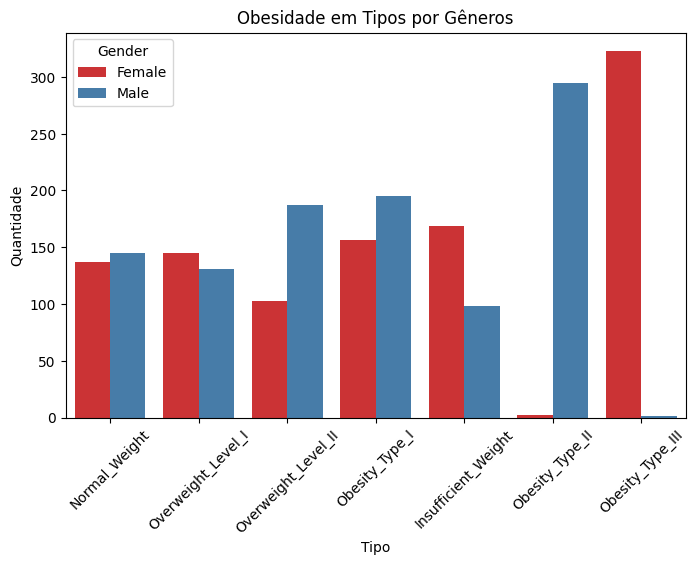

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Obesity', hue='Gender', palette='Set1')
plt.title('Obesidade em Tipos por Gêneros')
plt.xlabel('Tipo')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

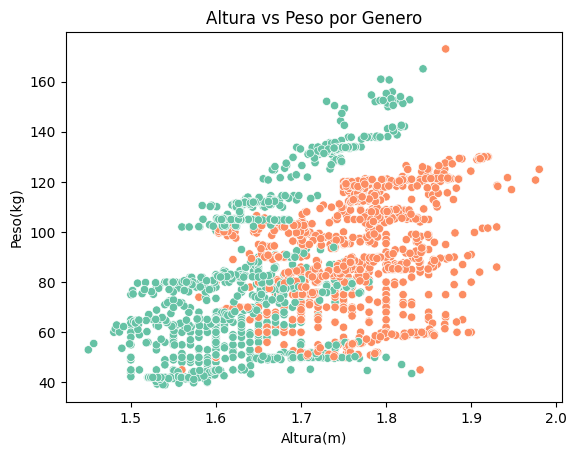

In [ ]:
sns.scatterplot(x='Height', y='Weight', hue='Gender',palette='Set2', data=df, legend = False)

#plt.legend(title="Gênero")

plt.title('Altura vs Peso por Genero')
plt.xlabel('Altura(m)')
plt.ylabel('Peso(kg)')

plt.show()

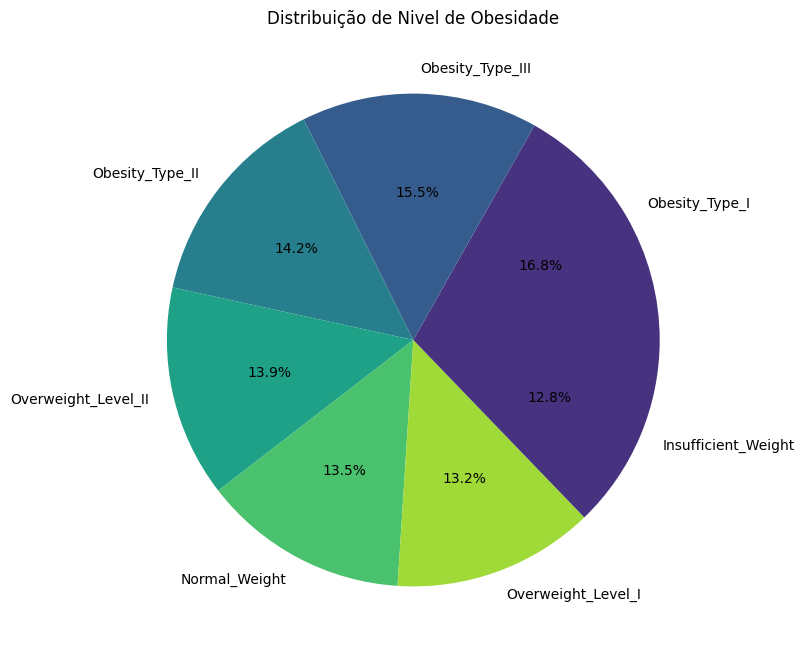

In [ ]:
plt.figure(figsize=(8, 8))
df['Obesity'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis'))
plt.title('Distribuição de Nivel de Obesidade')
plt.ylabel('')
plt.show()

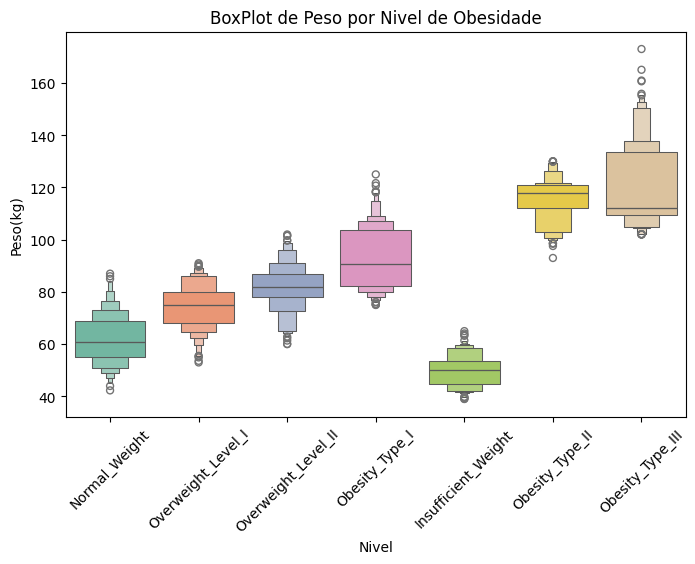

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxenplot(data=df, x='Obesity', y='Weight', hue='Obesity', palette='Set2')
plt.title('BoxPlot de Peso por Nivel de Obesidade')
plt.xlabel('Nivel')
plt.ylabel('Peso(kg)')
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 54.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 57.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 54.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 57.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 69.3% of the points cannot be plac

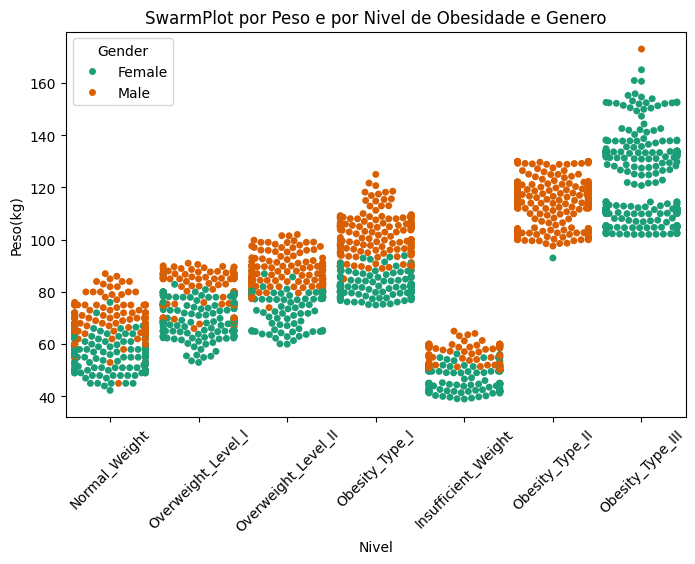

In [ ]:
plt.figure(figsize=(8, 5))
sns.swarmplot(data=df, x='Obesity', y='Weight', hue='Gender', palette='Dark2')
plt.title('SwarmPlot por Peso e por Nivel de Obesidade e Genero')
plt.xlabel('Nivel')
plt.ylabel('Peso(kg)')
plt.xticks(rotation=45)
plt.show()

<Axes: >

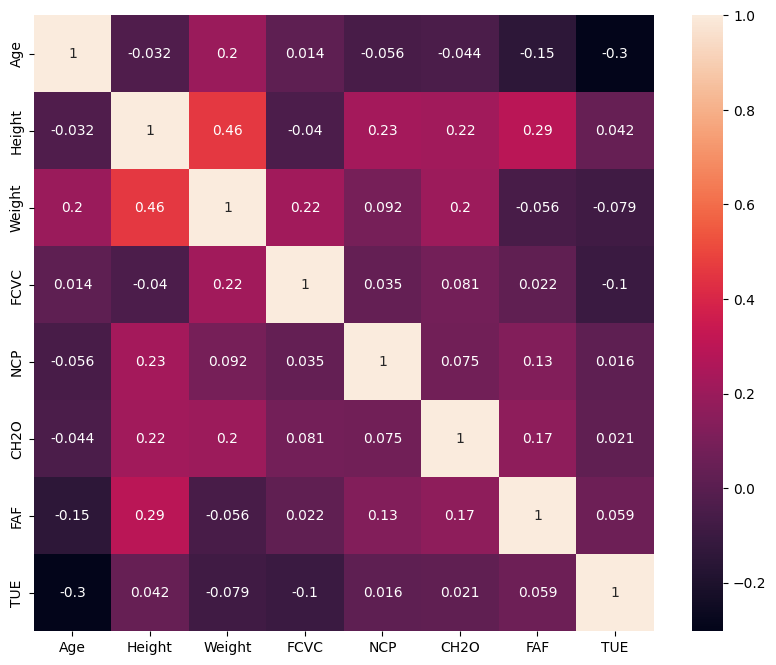

In [ ]:
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(df.corr(numeric_only = True), annot=True)

In [ ]:
#Criação de classe para mudança de objects para float64
class ObjectToFloatTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoders = {}
        self.columns_to_encode = []

    def fit(self, X, y=None):
        self.columns_to_encode = [col for col in X.columns if X[col].dtype == "object"]
        for col in self.columns_to_encode:
            le = LabelEncoder()
            le.fit(X[col])
            self.encoders[col] = le

        return self

    def transform(self, X):
        X_transformed = X.copy()
        for col in self.columns_to_encode:
            if col in X_transformed.columns and col in self.encoders:
                X_transformed[col] = self.encoders[col].transform(X_transformed[col])
                X_transformed[col] = X_transformed[col].astype('float64')
            else:
                pass
        return X_transformed


df_copy_for_encoding = df.copy()
object_transformer = ObjectToFloatTransformer()
df_encoded_class_version = object_transformer.fit_transform(df_copy_for_encoding)

print("\n DF original info:")
df.info()
print("\n DF transformado info:")
df_encoded_class_version.info()
print("\n Head DF transformada:")
print(df_encoded_class_version.head())


 DF original info:
<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2087 non-null   object 
 1   Age             2087 non-null   float64
 2   Height          2087 non-null   float64
 3   Weight          2087 non-null   float64
 4   family_history  2087 non-null   object 
 5   FAVC            2087 non-null   object 
 6   FCVC            2087 non-null   float64
 7   NCP             2087 non-null   float64
 8   CAEC            2087 non-null   object 
 9   SMOKE           2087 non-null   object 
 10  CH2O            2087 non-null   float64
 11  SCC             2087 non-null   object 
 12  FAF             2087 non-null   float64
 13  TUE             2087 non-null   float64
 14  CALC            2087 non-null   object 
 15  MTRANS          2087 non-null   object 
 16  Obesity         2087 non-null   object 
dtypes: float64(8), obj

In [ ]:
#Extraindo dataframe editado e tratado
df_encoded_class_version.to_csv('df_clean.csv', index=False)

In [ ]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df_encoded_class_version.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,0.0,21.0,1.62,64.0,1.0,0.0,2.0,3.0,2.0,0.0,2.0,0.0,0.0,1.0,3.0,3.0,1.0
1,0.0,21.0,1.52,56.0,1.0,0.0,3.0,3.0,2.0,1.0,3.0,1.0,3.0,0.0,2.0,3.0,1.0
2,1.0,23.0,1.80,77.0,1.0,0.0,2.0,3.0,2.0,0.0,2.0,0.0,2.0,1.0,1.0,3.0,1.0
3,1.0,27.0,1.80,87.0,0.0,0.0,3.0,3.0,2.0,0.0,2.0,0.0,2.0,0.0,1.0,4.0,5.0
4,1.0,22.0,1.78,89.8,0.0,0.0,2.0,1.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,3.0,6.0


In [ ]:
'''

Algumas das colunas/caracteres estavam sendo classificadas como objects visto no .info(),
não conseguindo assim classificar e futuramente impactando para o treinamento do modelo
então foi feito um processo de encoding para transformar em base float64

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

        print(f"Coluna: {column}")
        print(f"Valor Unico Antes encoding: {df[column].astype('category').cat.categories.tolist()}")
        print(f"Valor Unico Depois encoding: {df[column].unique()}\n")


'''

<Axes: >

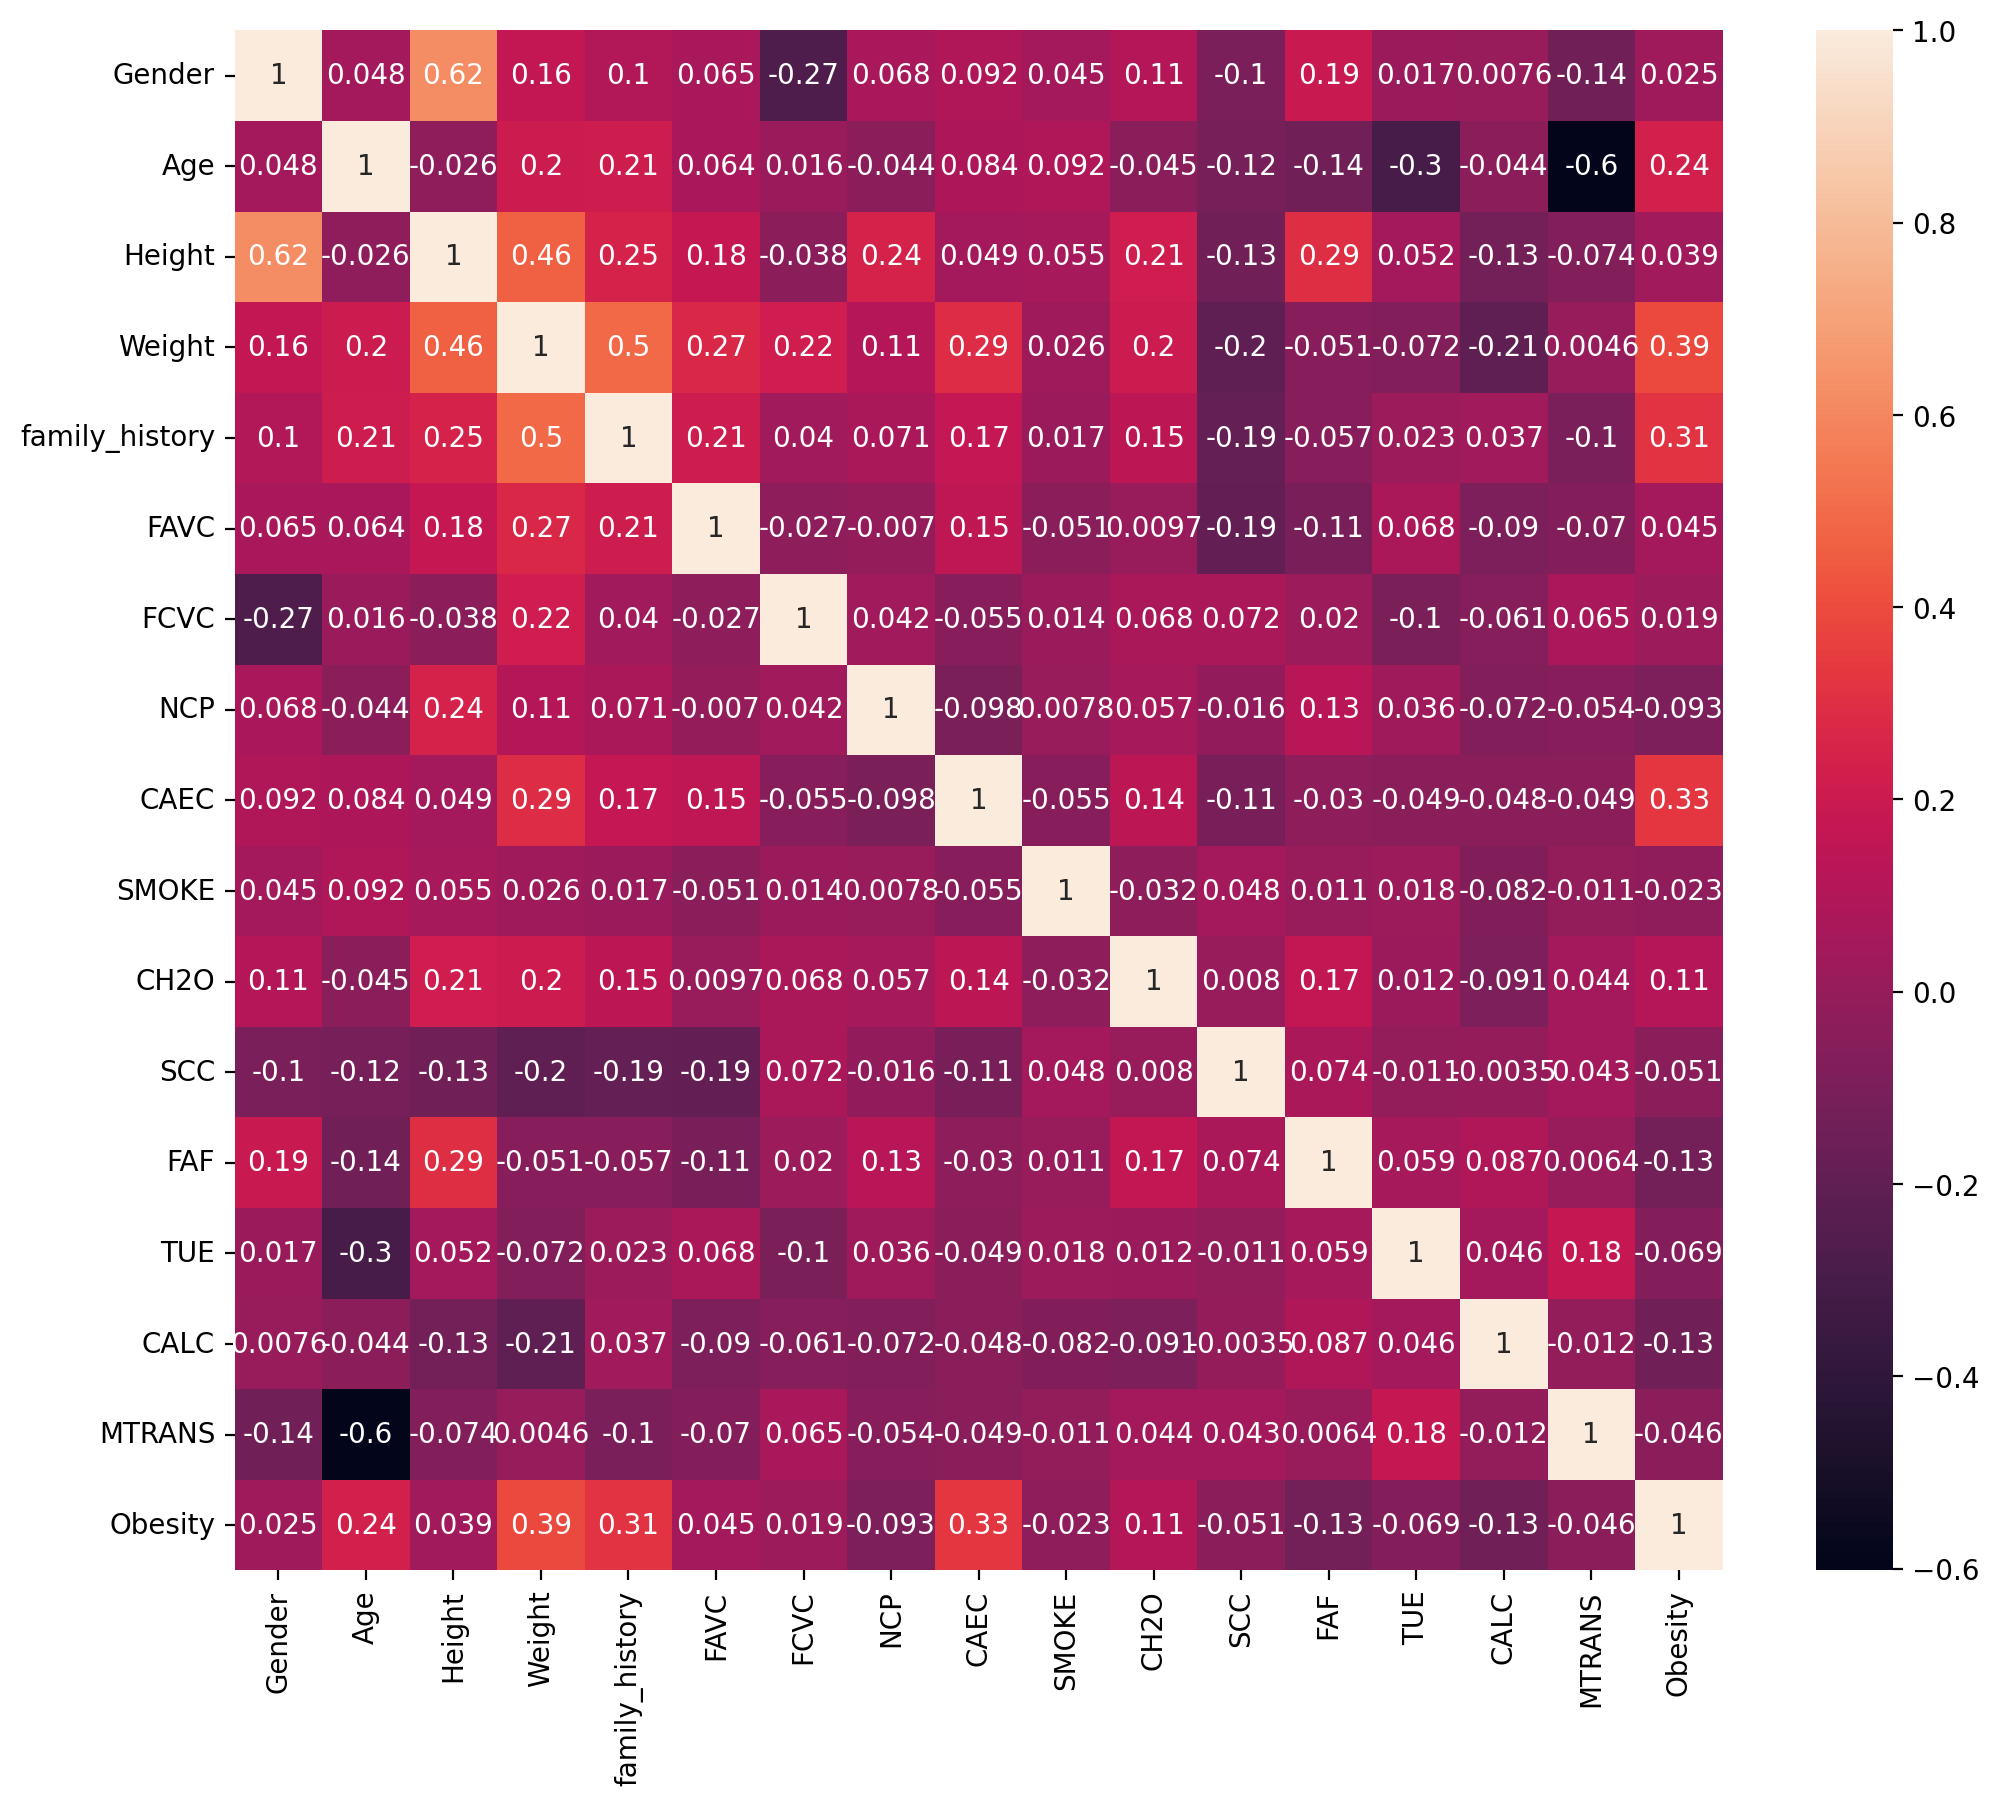

In [ ]:
plt.figure(figsize=(12, 10), dpi=200)
sns.heatmap(df_encoded_class_version.corr(), annot=True)

# Pipeline e ML

In [ ]:
#Criação da Pipeline dos dados para começar o treinameto do modelo
def pipeline_dados(df):
  pipeline = Pipeline([
    ('transform_object_float64', ObjectToFloatTransformer())
  ])
  df_pipeline = pipeline.fit_transform(df)
  return df_pipeline

In [ ]:
treino = pipeline_dados(df)

In [ ]:
X = treino.drop('Obesity', axis=1)
y = treino['Obesity']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Regressão Logistica

In [ ]:
log_reg = LogisticRegression(max_iter = 200)
log_reg.fit(scaled_X_train, y_train)

log_pred = log_reg.predict(scaled_X_test)

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.93      0.88        59
         1.0       0.84      0.61      0.70        61
         2.0       0.93      0.91      0.92        70
         3.0       0.97      1.00      0.98        64
         4.0       1.00      1.00      1.00        60
         5.0       0.73      0.75      0.74        55
         6.0       0.70      0.82      0.75        49

    accuracy                           0.86       418
   macro avg       0.86      0.86      0.85       418
weighted avg       0.87      0.86      0.86       418



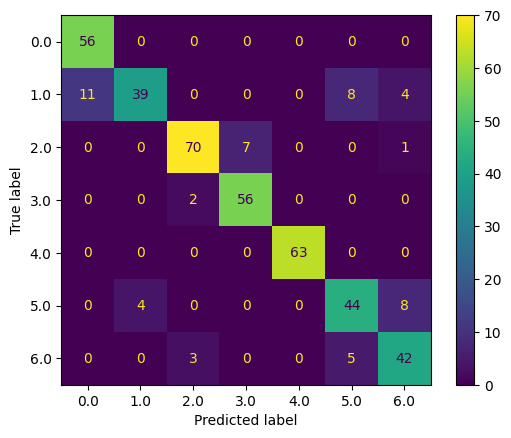

In [ ]:
ConfusionMatrixDisplay.from_estimator(log_reg, scaled_X_test, y_test)

## KNN

In [ ]:
num_neighbors = [1, 3, 5, 7, 9, 11, 13, 15]

for n in num_neighbors:
    test_knn = KNeighborsClassifier(n_neighbors = n)
    test_knn.fit(scaled_X_train, y_train)

    test_knn_pred = test_knn.predict(scaled_X_test)

    accuracy = accuracy_score(y_test, test_knn_pred)

    print(accuracy)

0.80622009569378
0.8205741626794258
0.8014354066985646
0.7799043062200957
0.7918660287081339
0.7822966507177034
0.777511961722488
0.7751196172248804


In [ ]:
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(scaled_X_train, y_train)

knn_pred = knn.predict(scaled_X_test)

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

         0.0       0.78      0.85      0.81        59
         1.0       0.65      0.36      0.46        61
         2.0       0.77      0.89      0.82        70
         3.0       0.95      0.97      0.96        64
         4.0       1.00      1.00      1.00        60
         5.0       0.80      0.75      0.77        55
         6.0       0.63      0.82      0.71        49

    accuracy                           0.81       418
   macro avg       0.80      0.80      0.79       418
weighted avg       0.80      0.81      0.80       418



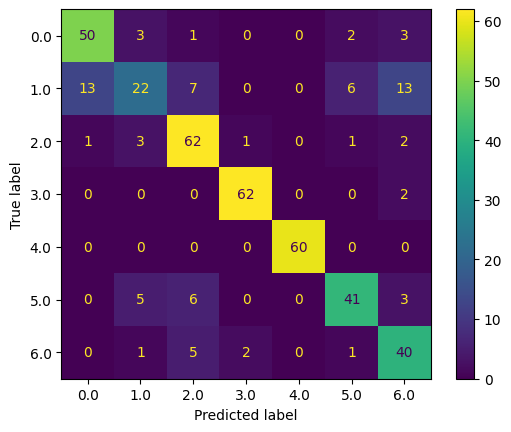

In [ ]:
ConfusionMatrixDisplay.from_estimator(knn, scaled_X_test, y_test)

## Random Forest

In [ ]:
rand_frst = RandomForestClassifier(n_estimators=100, random_state=42)
rand_frst.fit(X_train, y_train)

rand_pred = rand_frst.predict(X_test)

print(classification_report(y_test, rand_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97        56
         1.0       0.89      0.90      0.90        62
         2.0       0.99      0.97      0.98        78
         3.0       0.97      0.98      0.97        58
         4.0       1.00      1.00      1.00        63
         5.0       0.88      0.89      0.88        56
         6.0       0.98      0.96      0.97        50

    accuracy                           0.96       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.96      0.96      0.96       423



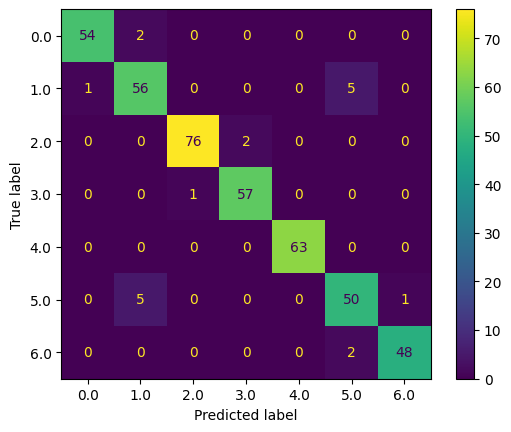

In [ ]:
ConfusionMatrixDisplay.from_estimator(rand_frst, X_test, y_test)

In [ ]:
joblib.dump(knn, 'knn.joblib')

['knn.joblib']